<a href="https://colab.research.google.com/github/beyzadurdu6619/ML/blob/main/mae_mape_mse_error_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#MSE RMSE MAE MAPE MODEL HATA FONK

 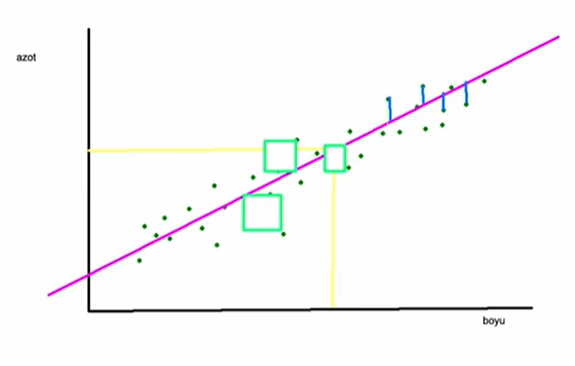

In [51]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [7]:
df=pd.read_csv('insurance.csv')

In [8]:
df.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df=pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)

In [11]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [12]:
y=df['charges']
x=df.drop('charges',axis=1)

In [13]:
l=LinearRegression()
model=l.fit(x,y)


In [14]:
model.score(x,y)

0.7509130345985207

In [15]:
model.predict([[19,26,0,1,1,0,0,1]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([24517.93110714])

In [38]:
df_hata=pd.DataFrame()

In [39]:
df_hata['sonuc']=y
y_tahmin=df_hata['tahmin']=model.predict(x)
fark=df_hata['hata']=(y-y_tahmin)




In [48]:
df_hata.head()

,sonuc,tahmin,hata,mse,mae,mape
0,16884.92400,25293.713028,-8408.789028,7.070773e+07,8408.789028,0.999911
1,1725.55230,3448.602834,-1723.050534,2.968903e+06,1723.050534,0.998842
2,4449.46200,6706.988491,-2257.526491,5.096426e+06,2257.526491,0.999661
3,21984.47061,3754.830163,18229.640447,3.323198e+08,18229.640447,0.999992
4,3866.85520,5592.493386,-1725.638186,2.977827e+06,1725.638186,0.999626


In [42]:
#MSE HATANIN KARESİ
df_hata['mse']=df_hata['hata']**2

In [43]:
#MAE ERROR MUTLAK DEĞERLİ HATA
df_hata['mae']=np.abs(df_hata['hata'])

In [47]:
#MAPE HATA ORANLARININ mutlak değeri
df_hata['mape']=np.abs((y-y_tahmin/y)/y)

In [49]:
df_hata.mean()

,0
sonuc,1.327042e+04
tahmin,1.327042e+04
hata,2.289371e-12
mse,3.650189e+07
mae,4.170887e+03
mape,9.997713e-01


In [52]:
mean_squared_error(y,y_tahmin)


36501893.00741544

In [53]:
mean_absolute_error(y,y_tahmin)

4170.886894163586

In [54]:
mean_absolute_percentage_error(y,y_tahmin)

0.4203526847372702